<a href="https://colab.research.google.com/github/ankithchowdharycs24-max/BIS_LAB/blob/main/Particleswarm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compute_otsu_fitness(thresholds, hist, total_pixels):
    thresholds = np.sort(np.clip(thresholds, 0, 255)).astype(int)
    bounds = [0] + list(thresholds) + [256]

    variance = 0.0
    global_mean = np.sum(np.arange(256) * hist) / total_pixels

    for i in range(len(bounds) - 1):
        bin_range = np.arange(bounds[i], bounds[i+1])
        if len(bin_range) == 0:
            continue
        weight = np.sum(hist[bin_range]) / total_pixels
        if weight == 0:
            continue
        mean = np.sum(bin_range * hist[bin_range]) / (weight * total_pixels)
        variance += weight * (mean - global_mean) ** 2

    return variance

def pso_image_segmentation(image_path, num_thresholds=2, num_particles=20, max_iter=30):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()
    total_pixels = img.size

    w, c1, c2 = 0.7, 1.5, 1.5

    positions = np.random.uniform(10, 245, (num_particles, num_thresholds))
    velocities = np.random.uniform(-5, 5, (num_particles, num_thresholds))

    p_best_positions = np.copy(positions)
    p_best_fitnesses = np.array([compute_otsu_fitness(p, hist, total_pixels) for p in positions])

    g_best_idx = np.argmax(p_best_fitnesses)
    g_best_pos = np.copy(p_best_positions[g_best_idx])
    g_best_fit = p_best_fitnesses[g_best_idx]

    for _ in range(max_iter):
        for i in range(num_particles):
            r1, r2 = np.random.rand(num_thresholds), np.random.rand(num_thresholds)
            velocities[i] = (w * velocities[i] +
                             c1 * r1 * (p_best_positions[i] - positions[i]) +
                             c2 * r2 * (g_best_pos - positions[i]))

            positions[i] = np.clip(positions[i] + velocities[i], 0, 255)
            fitness = compute_otsu_fitness(positions[i], hist, total_pixels)

            if fitness > p_best_fitnesses[i]:
                p_best_fitnesses[i] = fitness
                p_best_positions[i] = np.copy(positions[i])

                if fitness > g_best_fit:
                    g_best_fit = fitness
                    g_best_pos = np.copy(positions[i])

    final_thresholds = np.sort(g_best_pos).astype(int)
    print(f"Optimal Thresholds: {final_thresholds}")

    segmented_img = np.zeros_like(img)
    bounds = [0] + list(final_thresholds) + [255]
    color_steps = 255 // num_thresholds

    for i in range(len(bounds) - 1):
        segmented_img[(img >= bounds[i]) & (img <= bounds[i+1])] = i * color_steps

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Grayscale")
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Segmented ({num_thresholds} Thresholds)")
    plt.imshow(segmented_img, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Optimal Thresholds: [ 78 113 155]


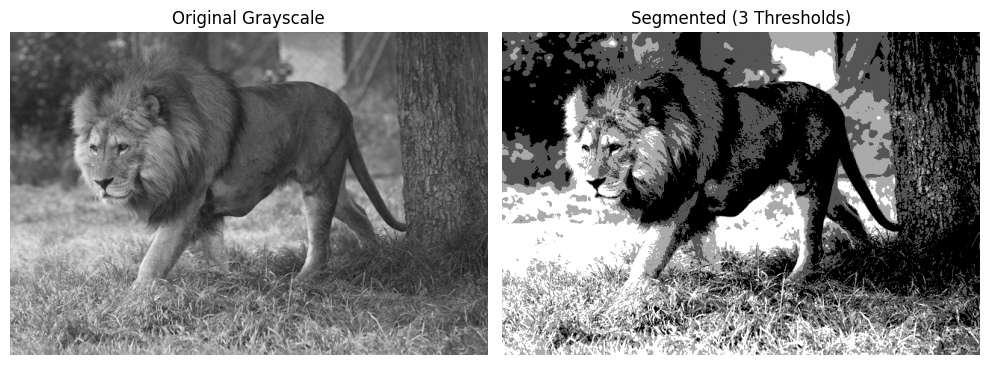

In [10]:
import urllib.request

# Direct high-quality public domain lion image from Unsplash
url = 'https://images.unsplash.com/photo-1546182990-dffeafbe841d?q=80&w=640&auto=format&fit=crop'
image_path = 'sample_lion.png'

req = urllib.request.Request(
    url,
    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
)

with urllib.request.urlopen(req) as response, open(image_path, 'wb') as out_file:
    out_file.write(response.read())

pso_image_segmentation(image_path, num_thresholds=3, num_particles=25, max_iter=20)